# Feature Analysis & Visualization

**Project:** Fraudulent Donation Link Detection Using AI  
**Purpose:** for every feature built so far, visualize *how well it separates legitimate links from scam links*, and export CSVs split by each feature.

**Label convention:** `0 = Legitimate`, `1 = Scam / Fraudulent`.

**Note on data source:** this notebook now **loads `Feature_Table.csv`** rather than rebuilding features from scratch, because the WHOIS-based features (domain age, registrar) take ~25 minutes of network lookups to regenerate. Two experimental features (`tld_length`, `two_letter_tld`) are computed here since they're cheap and are analysis-only.

**Sentinel values:** some features use negatives to mean *"no data"* rather than a real measurement:
- `domain_age_days` / `domain_expiry_days`: `-1` = WHOIS lookup failed
- `registrar_phishing_score`: `-2` = no WHOIS data, `-1` = registrar not tracked by Cybercrime Info Center

These are plotted separately from real values, so they don't distort the averages.

In [4]:
# ---- Setup ----
import pandas as pd
import re, os
from urllib.parse import urlparse
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.edgecolor": "#888", "axes.linewidth": 0.8,
})

# Load the FULL feature table (built in Feature_Table.ipynb)
DATA_PATH = r"E:\UNMC Internship Document\Github Upload\notebooks\Feature Table 5.csv"       # EDIT if your file is elsewhere
df = pd.read_csv(DATA_PATH)

# tidy: drop the CSV index column, standardise column names to snake_case
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")
df = df.rename(columns={
    "Special Character Count":  "special_character_count",
    "Suspicious Keyword Count": "suspicious_keyword_count",
    "Unknown Registrar Status": "unknown_registrar",
    "TLD Phishing Score":       "tld_phishing_score",
})

print("Loaded:", df.shape)
print(df["label"].value_counts().rename({0: "Legit", 1: "Scam"}))
print("\nColumns:", df.columns.tolist())
df.head()

Loaded: (804, 14)
label
Scam     441
Legit    363
Name: count, dtype: int64

Columns: ['url', 'label', 'url_length', 'has_https', 'num_subdomains', 'special_character_count', 'suspicious_keyword_count', 'domain_age_days', 'domain_expiry_days', 'registrar', 'unknown_registrar', 'registrar_phishing_score', 'tld', 'tld_phishing_score']


,url,label,url_length,has_https,num_subdomains,special_character_count,suspicious_keyword_count,domain_age_days,domain_expiry_days,registrar,unknown_registrar,registrar_phishing_score,tld,tld_phishing_score
0,https://www.icecream.com,0,24,1,1,5,0,11380,308,nom-iq dba com laude,0,1.00,com,11.66
1,https://proud-lake-5717.kx7hcssq.workers.dev/,1,45,1,2,9,0,-1,-1,unknown,1,-2.00,dev,7.49
2,https://www.stmusic.at,0,22,1,1,5,0,-1,-1,world4you internet services gmbh ( https://nic...,0,-1.00,at,2.16
3,http://icuwtzw.cloudaccess.host/,1,32,0,1,6,0,4223,524,enom,0,3.84,host,-1.00
4,http://bcc56.freehostpro.com/,1,29,0,1,6,0,7927,107,enom,0,3.84,com,11.66


## 1. Analysis-only features

These two aren't in the model's feature table — they're experiments kept here to document the research.

In [5]:
# ---- Experimental features (analysis only, cheap to compute) ----
def get_tld_length(url):
    host = urlparse(url).netloc
    return len(host.split(".")[-1]) if "." in host else 0

def get_two_letter_tld(url):
    # 1 if the URL has a 2-letter country-code TLD (.us, .uk, .at ...)
    return 1 if re.findall(r"\.[a-zA-Z]{2}\b", url) else 0

df["tld_length"]     = df["url"].apply(get_tld_length)
df["two_letter_tld"] = df["url"].apply(get_two_letter_tld)
df[["url", "tld_length", "two_letter_tld"]].head()

,url,tld_length,two_letter_tld
0,https://www.icecream.com,3,0
1,https://proud-lake-5717.kx7hcssq.workers.dev/,3,0
2,https://www.stmusic.at,2,1
3,http://icuwtzw.cloudaccess.host/,4,0
4,http://bcc56.freehostpro.com/,3,0


In [6]:
# ---- Output folder + styled helper functions ----
OUT = "../outputs/feature_analysis"
os.makedirs(OUT, exist_ok=True)

LEGIT_C, SCAM_C, ACCENT = "#3B82C4", "#E05252", "#8E5FD0"

def _style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

def trim_outliers(data, feature):
    """Rows within 1.5*IQR (the standard outlier rule). Used ONLY for clearer
    visuals — the model still trains on the full, untrimmed data."""
    q1, q3 = data[feature].quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return data
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return data[(data[feature] >= lo) & (data[feature] <= hi)]

def value_summary(df, feature):
    g = df.groupby(feature)["label"].agg(count="count", scam="sum")
    g["legit"] = g["count"] - g["scam"]
    g["scam_rate"] = (g["scam"] / g["count"]).round(3)
    return g[["count", "legit", "scam", "scam_rate"]]

def bin_summary(df, feature, bins=6):
    tmp = df.copy()
    tmp["bin"] = pd.cut(tmp[feature], bins=bins)
    g = tmp.groupby("bin", observed=True)["label"].agg(count="count", scam="sum")
    g["legit"] = g["count"] - g["scam"]
    g["scam_rate"] = (g["scam"] / g["count"]).round(3)
    return g[["count", "legit", "scam", "scam_rate"]]

def plot_numeric(df, feature):
    """For a continuous feature: an easy-to-read average comparison + a clean box plot."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
    # LEFT: average value per class (easy to read)
    stats = df.groupby("label")[feature].agg(["mean", "median"])
    x, w = [0, 1], 0.35
    ax[0].bar([i - w/2 for i in x], stats["mean"],   w, label="mean",   color=LEGIT_C, edgecolor="white")
    ax[0].bar([i + w/2 for i in x], stats["median"], w, label="median", color=SCAM_C,  edgecolor="white")
    ax[0].set_xticks(x); ax[0].set_xticklabels(["Legit", "Scam"])
    ax[0].set_title(f"Average {feature} by class"); ax[0].set_ylabel(feature); ax[0].legend(frameon=False)
    for i in x:
        ax[0].text(i - w/2, stats["mean"].iloc[i],   f"{stats['mean'].iloc[i]:.0f}",   ha="center", va="bottom", fontsize=9)
        ax[0].text(i + w/2, stats["median"].iloc[i], f"{stats['median'].iloc[i]:.0f}", ha="center", va="bottom", fontsize=9)
    _style(ax[0])
    # RIGHT: box plot with outliers hidden so the boxes are actually visible
    ax[1].boxplot([df[df.label == 0][feature], df[df.label == 1][feature]],
                  labels=["Legit", "Scam"], showfliers=False, patch_artist=True,
                  boxprops=dict(facecolor="#EAF1FA", edgecolor=LEGIT_C),
                  medianprops=dict(color=SCAM_C, linewidth=2))
    ax[1].set_title(f"{feature} spread (outliers hidden)"); ax[1].set_ylabel(feature)
    _style(ax[1])
    fig.suptitle(feature, fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(f"{OUT}/{feature}_plot.png", dpi=130, bbox_inches="tight")
    plt.show()

def plot_discrete(df, feature):
    """For a binary/discrete feature: counts by class + scam rate per value."""
    ct = pd.crosstab(df[feature], df["label"])
    rate = df.groupby(feature)["label"].mean()
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
    ct.plot(kind="bar", ax=ax[0], color=[LEGIT_C, SCAM_C], width=0.8, edgecolor="white")
    ax[0].set_title("Counts by class"); ax[0].set_xlabel(feature); ax[0].set_ylabel("count")
    ax[0].legend(["Legit (0)", "Scam (1)"], frameon=False); ax[0].tick_params(axis="x", rotation=0)
    _style(ax[0])
    ax[1].bar(rate.index.astype(str), rate.values, color=ACCENT, width=0.7, edgecolor="white")
    ax[1].set_ylim(0, 1.15)     # headroom so labels don't collide with the title
    ax[1].set_title("Scam rate by value"); ax[1].set_xlabel(feature); ax[1].set_ylabel("scam rate")
    for i, v in enumerate(rate.values):
        if v > 0.9:  # place label INSIDE the bar when it's near the top
            ax[1].text(i, v - 0.08, f"{v:.0%}", ha="center", color="white", fontweight="bold")
        else:
            ax[1].text(i, v + 0.03, f"{v:.0%}", ha="center", fontweight="bold")
    _style(ax[1])
    fig.suptitle(feature, fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(f"{OUT}/{feature}_plot.png", dpi=130, bbox_inches="tight")
    plt.show()

print("Helpers ready. Outputs ->", OUT)

def plot_with_sentinels(df, feature, sentinels=(-1,), bins=5):
    """For features where negative values are 'no data' FLAGS, not measurements.

    Plotting these normally is misleading: the -1s drag the average down and
    hide the real pattern. So we show scam rate for each sentinel group AND for
    binned real values — which also reveals non-linear (U-shaped) relationships
    that a correlation number would completely miss.
    """
    rows = []
    for s in sentinels:
        sub = df[df[feature] == s]
        if len(sub):
            rows.append((f"{s}\n(no data)", len(sub), sub["label"].mean()))

    real = df[~df[feature].isin(sentinels)]
    r = trim_outliers(real, feature)
    if len(r) > bins:
        r = r.assign(_b=pd.qcut(r[feature], q=bins, duplicates="drop"))
        for b, g in r.groupby("_b", observed=True):
            lo, hi = b.left, b.right
            rows.append((f"{lo:.0f} to\n{hi:.0f}", len(g), g["label"].mean()))

    labels = [r[0] for r in rows]; counts = [r[1] for r in rows]; rates = [r[2] for r in rows]
    colors = ["#9AA3B8" if "no data" in l else ACCENT for l in labels]

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
    ax[0].bar(range(len(rates)), rates, color=colors, width=.7, edgecolor="white")
    ax[0].set_xticks(range(len(labels))); ax[0].set_xticklabels(labels, fontsize=8.5)
    ax[0].set_ylim(0, 1.15); ax[0].set_ylabel("scam rate")
    ax[0].set_title(f"Scam rate by {feature} band")
    for i, v in enumerate(rates):
        ax[0].text(i, v + .03, f"{v:.0%}", ha="center", fontsize=8.5, fontweight="bold")
    _style(ax[0])

    ax[1].bar(range(len(counts)), counts, color=colors, width=.7, edgecolor="white")
    ax[1].set_xticks(range(len(labels))); ax[1].set_xticklabels(labels, fontsize=8.5)
    ax[1].set_ylabel("rows"); ax[1].set_title("How many links in each band")
    for i, v in enumerate(counts):
        ax[1].text(i, v, str(v), ha="center", va="bottom", fontsize=8.5)
    _style(ax[1])

    fig.suptitle(feature + "   (grey = no data)", fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(f"{OUT}/{feature}_plot.png", dpi=130, bbox_inches="tight")
    plt.show()

def sentinel_summary(df, feature, sentinels=(-1,)):
    """Summary table separating 'no data' rows from real measurements."""
    out = []
    for s in sentinels:
        sub = df[df[feature] == s]
        if len(sub):
            out.append({"band": f"{s} (no data)", "count": len(sub),
                        "legit": int((sub.label == 0).sum()), "scam": int((sub.label == 1).sum()),
                        "scam_rate": round(sub.label.mean(), 3)})
    real = df[~df[feature].isin(sentinels)]
    out.append({"band": "real values", "count": len(real),
                "legit": int((real.label == 0).sum()), "scam": int((real.label == 1).sum()),
                "scam_rate": round(real.label.mean(), 3)})
    return pd.DataFrame(out)


Helpers ready. Outputs -> ../outputs/feature_analysis


## 2. `url_length`   *(clearer plots)*

**Hypothesis:** scam links are often longer. The left chart compares the **average** length per class (easy to read); the right box plot shows the **spread** with extreme outliers hidden so the boxes are visible.

C:\Users\User\AppData\Local\Temp\ipykernel_25684\39641685.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([df[df.label == 0][feature], df[df.label == 1][feature]],


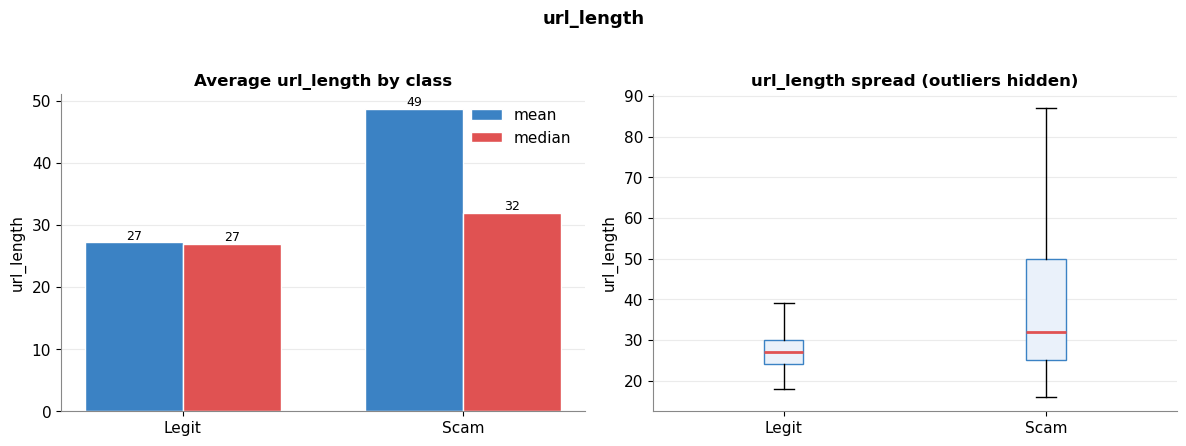

                  count  legit  scam  scam_rate
bin                                            
(13.963, 355.5]     802    363   439      0.547
(355.5, 695.0]        1      0     1      1.000
(1713.5, 2053.0]      1      0     1      1.000

Median = 28 | Mean length -> Legit: 27.2 | Scam: 48.7


In [7]:
plot_numeric(df, "url_length")

summary = bin_summary(df, "url_length", bins=6)
summary.to_csv(f"{OUT}/url_length_summary.csv")
print(summary)

med = df["url_length"].median()
df[df.url_length >  med][["url", "label"]].to_csv(f"{OUT}/url_length_long.csv",  index=False)
df[df.url_length <= med][["url", "label"]].to_csv(f"{OUT}/url_length_short.csv", index=False)
print(f"\nMedian = {med:.0f} | Mean length -> Legit:",
      round(df[df.label==0].url_length.mean(),1), "| Scam:", round(df[df.label==1].url_length.mean(),1))

## 3. `has_https`

**Hypothesis:** legitimate sites almost always use HTTPS; scam links more often skip it.

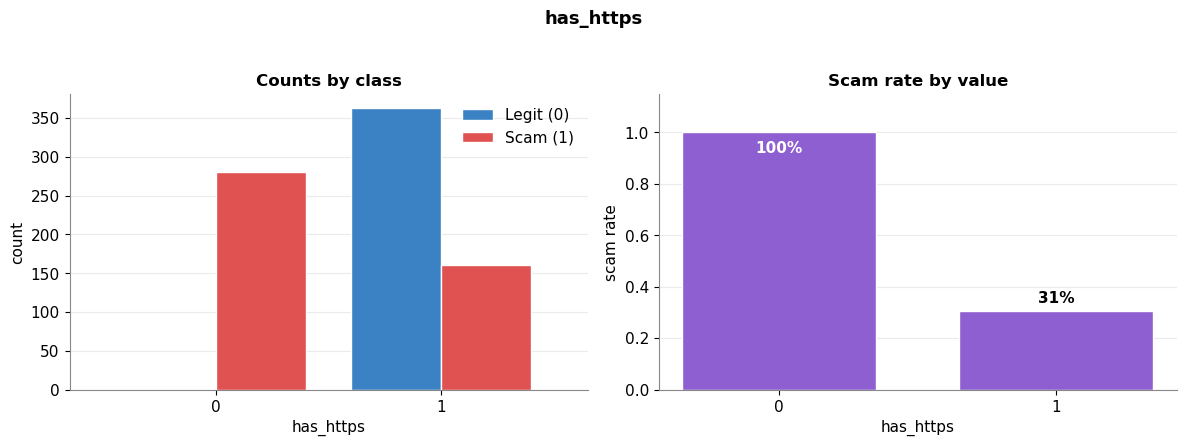

           count  legit  scam  scam_rate
has_https                               
0            280      0   280      1.000
1            524    363   161      0.307


In [8]:
plot_discrete(df, "has_https")

value_summary(df, "has_https").to_csv(f"{OUT}/has_https_summary.csv")
print(value_summary(df, "has_https"))

df[df.has_https == 1][["url", "label"]].to_csv(f"{OUT}/https_yes.csv", index=False)
df[df.has_https == 0][["url", "label"]].to_csv(f"{OUT}/https_no.csv",  index=False)

## 4. `num_subdomains`

**Hypothesis:** phishing links often stack more sub-domains.

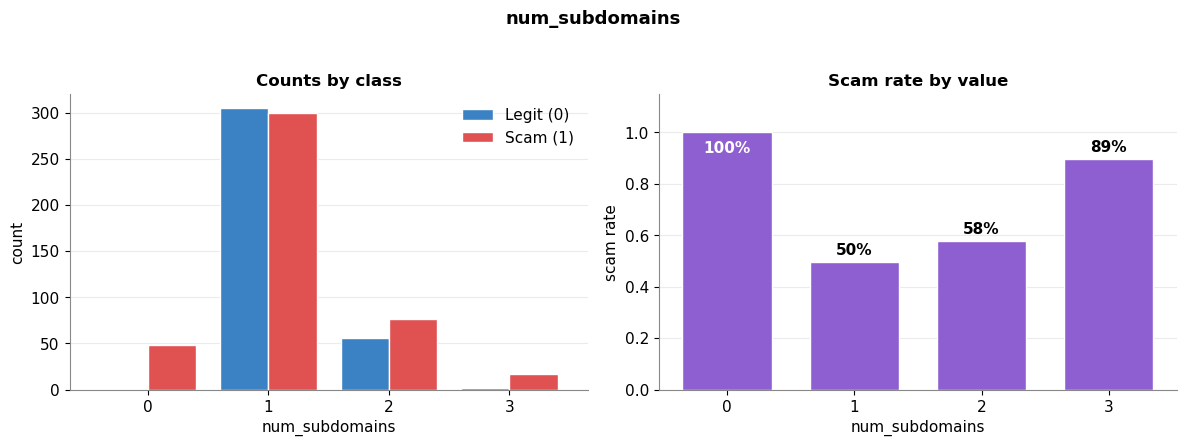

                count  legit  scam  scam_rate
num_subdomains                               
0                  48      0    48      1.000
1                 605    305   300      0.496
2                 132     56    76      0.576
3                  19      2    17      0.895


In [9]:
plot_discrete(df, "num_subdomains")

value_summary(df, "num_subdomains").to_csv(f"{OUT}/num_subdomains_summary.csv")
print(value_summary(df, "num_subdomains"))

df[df.num_subdomains >= 2][["url", "label"]].to_csv(f"{OUT}/subdomains_2plus.csv", index=False)
df[df.num_subdomains <  2][["url", "label"]].to_csv(f"{OUT}/subdomains_under2.csv", index=False)

## 5. `tld_length`   *(new feature)*

**What it is:** the length of the TLD — the last part of the host. `.com` = 3, `.uk` = 2, `.host` = 4, `.online` = 6.  
**Hypothesis:** scammers sometimes use unusual long TLDs (`.online`, `.click`, `.support`) or cheap country codes. We check whether TLD length differs between legit and scam.

*(Note: this is a richer version of `two_letter_tld` — instead of just "is it 2 letters?", it measures the actual length.)*

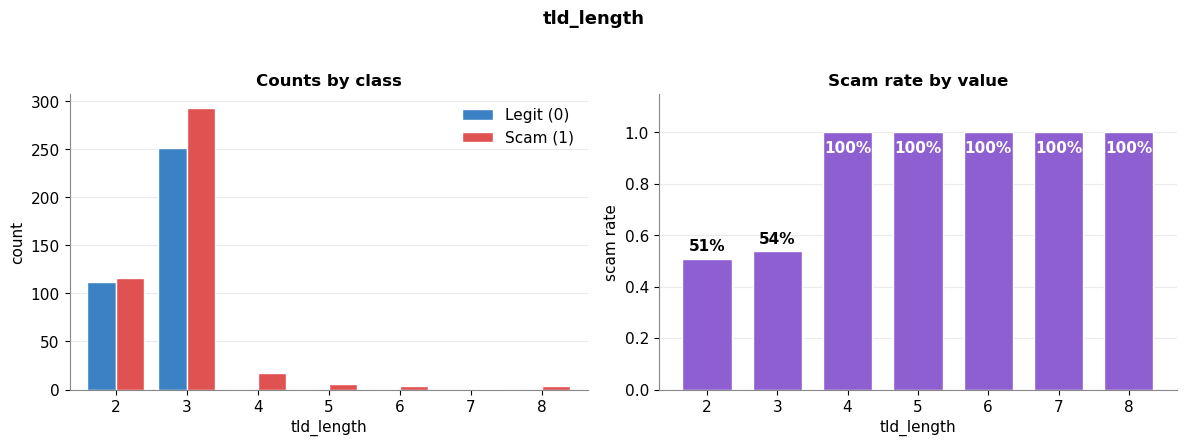

            count  legit  scam  scam_rate
tld_length                               
2             228    112   116      0.509
3             544    251   293      0.539
4              17      0    17      1.000
5               6      0     6      1.000
6               4      0     4      1.000
7               1      0     1      1.000
8               4      0     4      1.000


In [10]:
plot_discrete(df, "tld_length")   # discrete small values, so the bar view is clearest

value_summary(df, "tld_length").to_csv(f"{OUT}/tld_length_summary.csv")
print(value_summary(df, "tld_length"))

# split CSVs: standard TLD length (2-3, like .uk/.com) vs unusual (4+)
df[df.tld_length >= 4][["url", "label"]].to_csv(f"{OUT}/tld_length_long.csv",   index=False)
df[df.tld_length <  4][["url", "label"]].to_csv(f"{OUT}/tld_length_normal.csv", index=False)

## 6. `two_letter_tld`   *(Self Test)*

Turns your `\.[a-zA-Z]{2}\b` regex into a 0/1 feature and tests it across the **whole** dataset (your earlier `TwoLettersFiltered.csv` only looked inside the "yes" group).

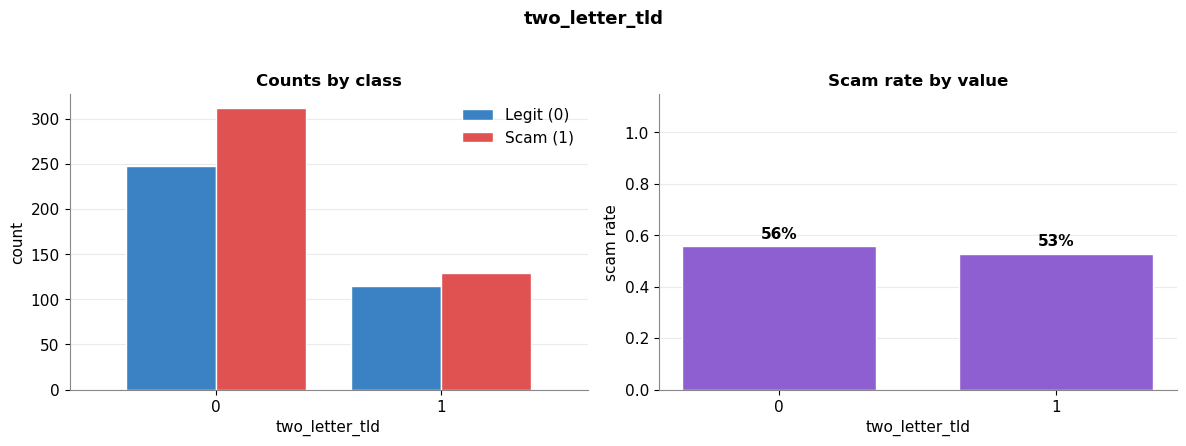

                count  legit  scam  scam_rate
two_letter_tld                               
0                 560    248   312      0.557
1                 244    115   129      0.529


In [11]:
plot_discrete(df, "two_letter_tld")

value_summary(df, "two_letter_tld").to_csv(f"{OUT}/two_letter_tld_summary.csv")
print(value_summary(df, "two_letter_tld"))

df[df.two_letter_tld == 1][["url", "label"]].to_csv(f"{OUT}/two_letter_tld_yes.csv", index=False)
df[df.two_letter_tld == 0][["url", "label"]].to_csv(f"{OUT}/two_letter_tld_no.csv",  index=False)

## 7. `special_character_count`  

**Hypothesis:** scam URLs are packed with special characters — dashes, digits, `%`, `@`, slashes. If so, the average count should be higher for scam links. Shown as an average comparison + a box plot with outliers hidden.

C:\Users\User\AppData\Local\Temp\ipykernel_25684\39641685.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([df[df.label == 0][feature], df[df.label == 1][feature]],


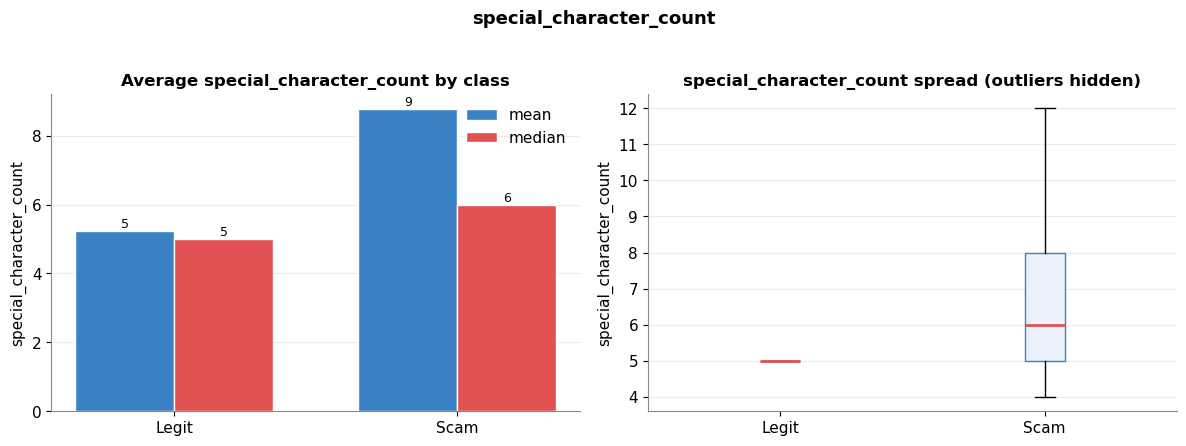

                  count  legit  scam  scam_rate
bin                                            
(3.329, 115.833]    803    363   440      0.548
(563.167, 675.0]      1      0     1      1.000

Median = 5 | Mean special chars -> Legit: 5.2 | Scam: 8.8


In [12]:
plot_numeric(df, "special_character_count")

bin_summary(df, "special_character_count", bins=6).to_csv(f"{OUT}/special_character_count_summary.csv")
print(bin_summary(df, "special_character_count", bins=6))

med = df["special_character_count"].median()
df[df.special_character_count >  med][["url", "label"]].to_csv(f"{OUT}/special_char_high.csv", index=False)
df[df.special_character_count <= med][["url", "label"]].to_csv(f"{OUT}/special_char_low.csv",  index=False)
print(f"\nMedian = {med:.0f} | Mean special chars -> Legit:",
      round(df[df.label==0].special_character_count.mean(),1),
      "| Scam:", round(df[df.label==1].special_character_count.mean(),1))

## 8. `suspicious_keyword_count` 

**Hypothesis:** scam URLs more often contain words like *donate, urgent, verify, login, gift*. Links with 1+ suspicious keyword should skew more towards scam.

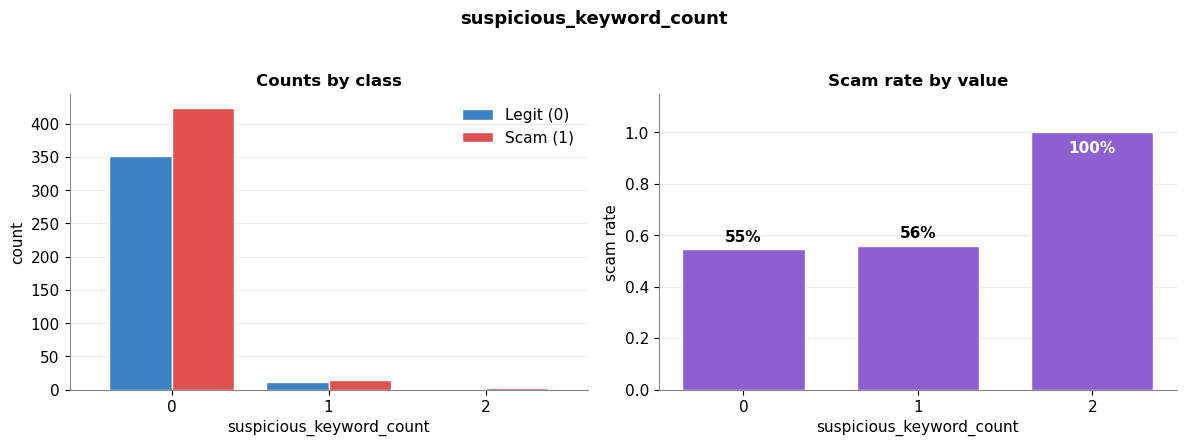

                          count  legit  scam  scam_rate
suspicious_keyword_count                               
0                           776    352   424      0.546
1                            25     11    14      0.560
2                             3      0     3      1.000


In [13]:
plot_discrete(df, "suspicious_keyword_count")

value_summary(df, "suspicious_keyword_count").to_csv(f"{OUT}/suspicious_keyword_count_summary.csv")
print(value_summary(df, "suspicious_keyword_count"))

df[df.suspicious_keyword_count >= 1][["url", "label"]].to_csv(f"{OUT}/has_suspicious_keyword.csv", index=False)
df[df.suspicious_keyword_count == 0][["url", "label"]].to_csv(f"{OUT}/no_suspicious_keyword.csv",  index=False)

## 9. `domain_age_days`  *(WHOIS)*

**Hypothesis:** fraudulent sites are registered days or weeks before a campaign; real charities are years old. `-1` = WHOIS lookup failed, shown separately in grey.

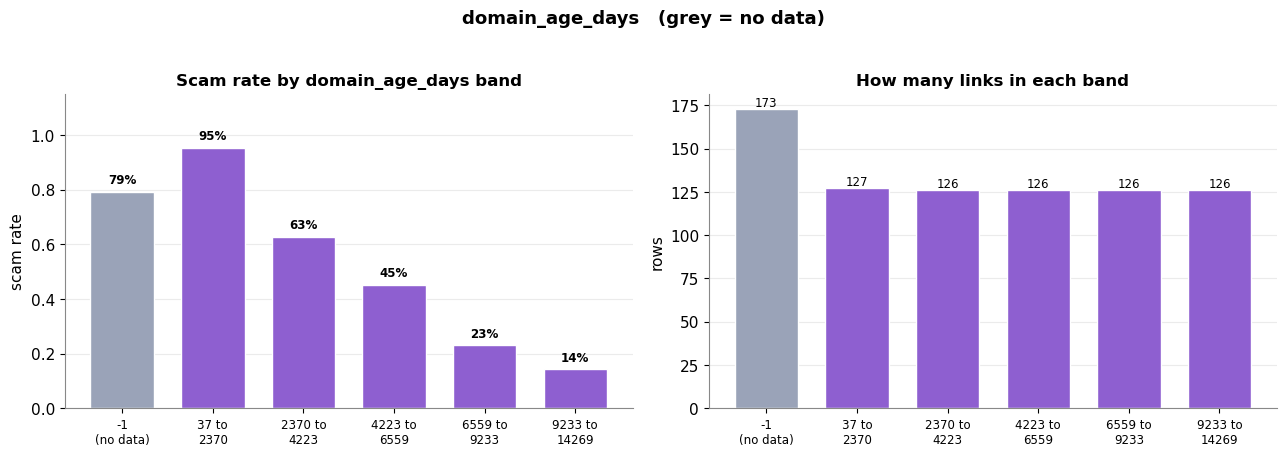

        band  count  legit  scam  scam_rate
-1 (no data)    173     36   137      0.792
 real values    631    327   304      0.482

Mean age -> Legit: 7415 days | Scam: 3626 days


In [14]:
plot_with_sentinels(df, "domain_age_days", sentinels=(-1,), bins=5)

sentinel_summary(df, "domain_age_days", (-1,)).to_csv(f"{OUT}/domain_age_days_summary.csv", index=False)
print(sentinel_summary(df, "domain_age_days", (-1,)).to_string(index=False))

real = df[df.domain_age_days != -1]
print("\nMean age -> Legit:", round(real[real.label==0].domain_age_days.mean()),
      "days | Scam:", round(real[real.label==1].domain_age_days.mean()), "days")

df[df.domain_age_days.between(0, 365)][["url","label"]].to_csv(f"{OUT}/domain_under_1year.csv", index=False)
df[df.domain_age_days > 365][["url","label"]].to_csv(f"{OUT}/domain_over_1year.csv", index=False)

## 10. `domain_expiry_days`  *(WHOIS)*

**Hypothesis:** scam domains are registered for the minimum term, so they expire sooner. `-1` = lookup failed.

> **Caveat:** real values can be negative (an already-expired domain), so `-1` is ambiguous — it could mean "no data" *or* "expired yesterday". Worth noting as a limitation.

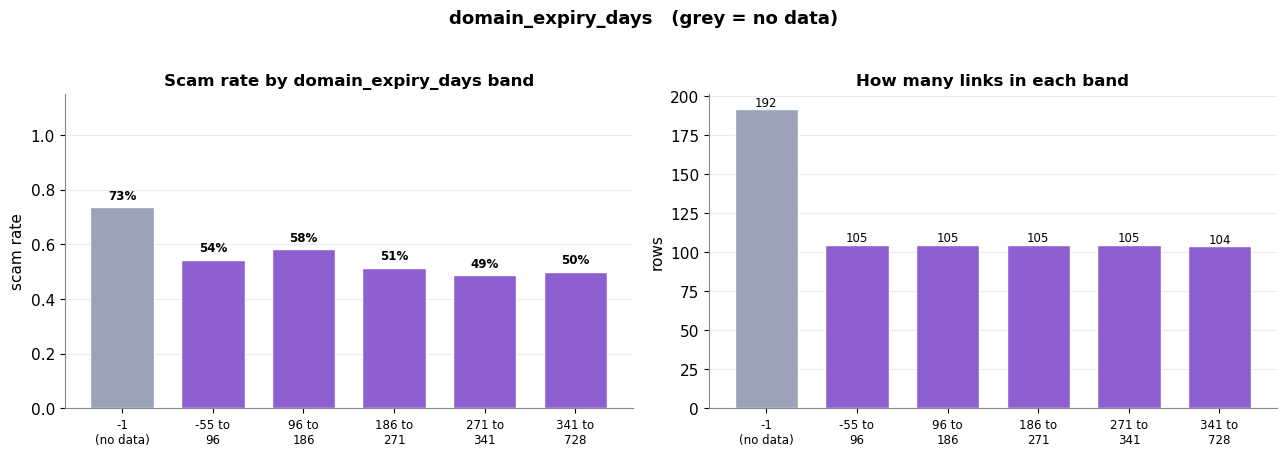

        band  count  legit  scam  scam_rate
-1 (no data)    192     51   141      0.734
 real values    612    312   300      0.490


In [15]:
plot_with_sentinels(df, "domain_expiry_days", sentinels=(-1,), bins=5)

sentinel_summary(df, "domain_expiry_days", (-1,)).to_csv(f"{OUT}/domain_expiry_days_summary.csv", index=False)
print(sentinel_summary(df, "domain_expiry_days", (-1,)).to_string(index=False))

## 11. `unknown_registrar`

**Hypothesis:** if WHOIS can't find a registrar at all, the domain is suspicious — free-hosting subdomains (`workers.dev`, `pages.dev`) have no registration record of their own, and scammers use them heavily.

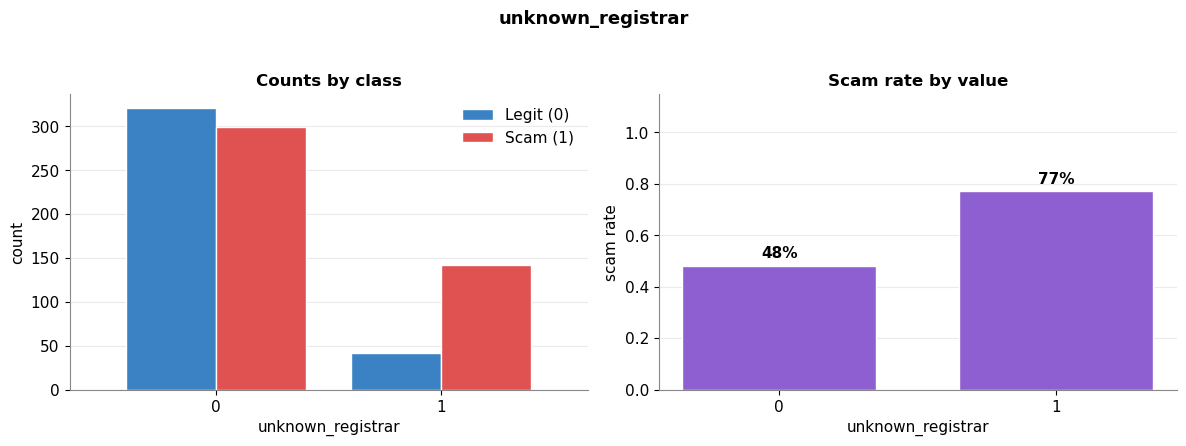

                   count  legit  scam  scam_rate
unknown_registrar                               
0                    620    321   299      0.482
1                    184     42   142      0.772


In [16]:
plot_discrete(df, "unknown_registrar")

value_summary(df, "unknown_registrar").to_csv(f"{OUT}/unknown_registrar_summary.csv")
print(value_summary(df, "unknown_registrar"))

df[df.unknown_registrar == 1][["url","label"]].to_csv(f"{OUT}/registrar_unknown.csv", index=False)
df[df.unknown_registrar == 0][["url","label"]].to_csv(f"{OUT}/registrar_known.csv",   index=False)

## 12. `registrar_phishing_score`  *(external data — Cybercrime Information Center)*

**Source:** Interisle / Cybercrime Information Center *Phishing Landscape*, Feb–Apr 2026 registrar tables. The score is phishing domains normalised by domains under management.

**Encoding:** `-2` = no WHOIS data · `-1` = registrar not tracked by CIC · `≥0` = published score.

> **Watch for a U-shape.** Scam rate is high at `-2`, dips for low scores, then climbs again for high scores. A correlation number reports ≈0 and misses this entirely — but a Decision Tree can split on both arms, so the feature is more useful than its correlation suggests.

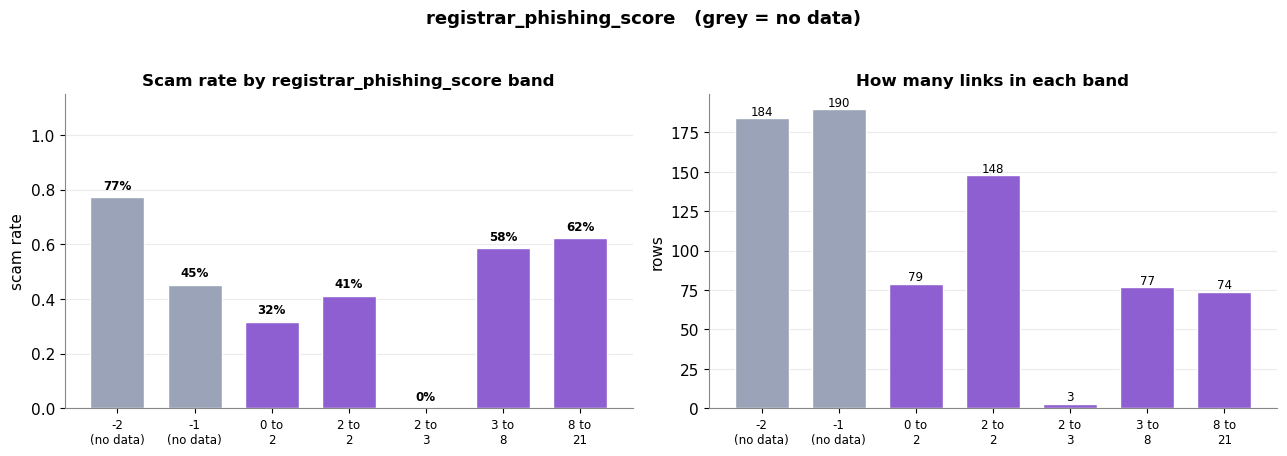

        band  count  legit  scam  scam_rate
-2 (no data)    184     42   142      0.772
-1 (no data)    190    104    86      0.453
 real values    430    217   213      0.495

Mean score -> Legit: 8.0 | Scam: 24.03


In [17]:
plot_with_sentinels(df, "registrar_phishing_score", sentinels=(-2, -1), bins=5)

sentinel_summary(df, "registrar_phishing_score", (-2,-1)).to_csv(f"{OUT}/registrar_phishing_score_summary.csv", index=False)
print(sentinel_summary(df, "registrar_phishing_score", (-2,-1)).to_string(index=False))

real = df[df.registrar_phishing_score > -1]
print("\nMean score -> Legit:", round(real[real.label==0].registrar_phishing_score.mean(), 2),
      "| Scam:", round(real[real.label==1].registrar_phishing_score.mean(), 2))

df[df.registrar_phishing_score >= 10][["url","registrar","label"]].to_csv(f"{OUT}/registrar_high_phishing.csv", index=False)

## 13. `tld_phishing_score`  *(external data — Cybercrime Information Center)*

**Source:** the CIC TLD tables (Feb–Apr 2026). Measures how much phishing is reported on each TLD, normalised by size. `-1` = TLD not in the CIC tables.

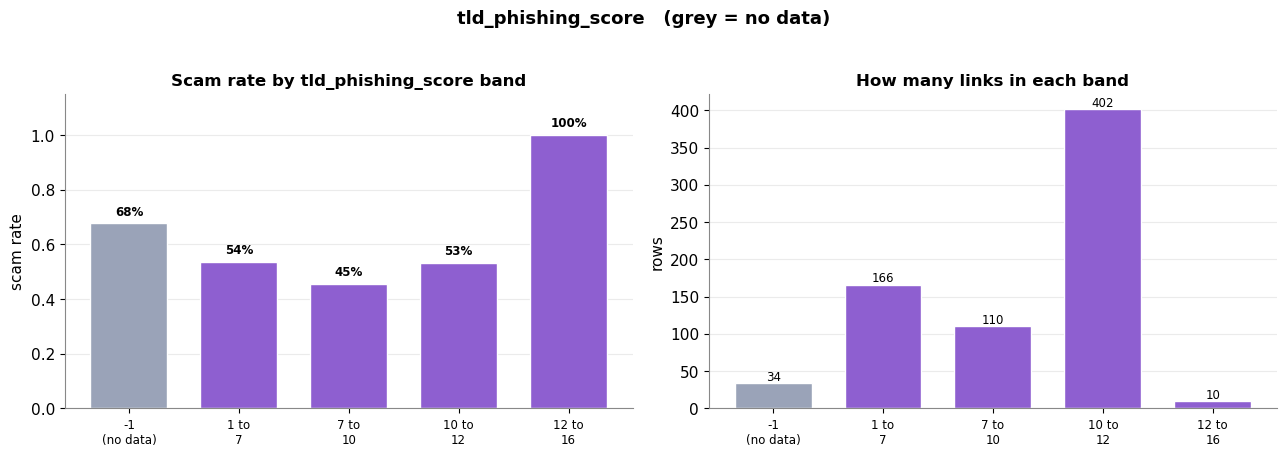

        band  count  legit  scam  scam_rate
-1 (no data)     34     11    23      0.676
 real values    770    352   418      0.543


In [18]:
plot_with_sentinels(df, "tld_phishing_score", sentinels=(-1,), bins=5)

sentinel_summary(df, "tld_phishing_score", (-1,)).to_csv(f"{OUT}/tld_phishing_score_summary.csv", index=False)
print(sentinel_summary(df, "tld_phishing_score", (-1,)).to_string(index=False))

## 14. Overall comparison — which features separate best?

Correlation of each feature with the label. Longest bar = strongest *linear* separator.

> **Important caveat:** correlation only measures straight-line relationships. Features with sentinel values (`domain_age_days`, `registrar_phishing_score`) have **non-linear, U-shaped** patterns that correlation scores near zero — but a Decision Tree can still split on them effectively. Read this chart alongside the per-feature scam-rate plots above, not instead of them.

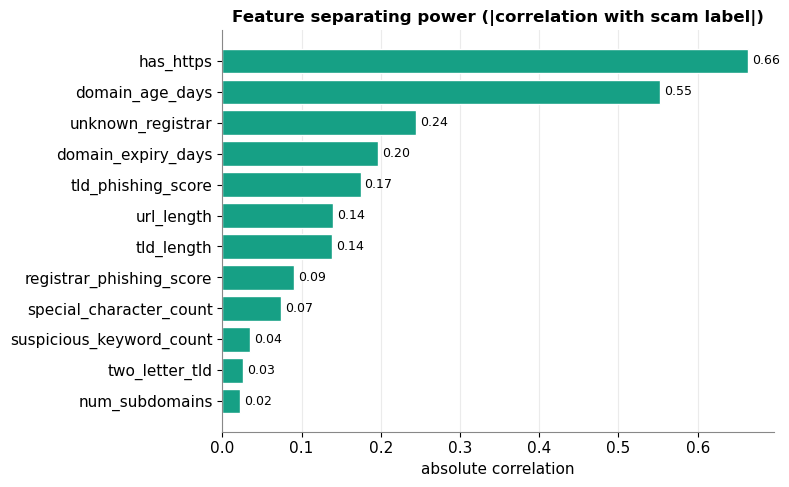

                 feature  correlation_with_scam  abs_strength
               has_https                 -0.663         0.663
         domain_age_days                 -0.552         0.552
       unknown_registrar                  0.244         0.244
      domain_expiry_days                 -0.196         0.196
      tld_phishing_score                  0.174         0.174
              url_length                  0.140         0.140
              tld_length                  0.138         0.138
registrar_phishing_score                  0.091         0.091
 special_character_count                  0.074         0.074
suspicious_keyword_count                  0.035         0.035
          two_letter_tld                 -0.026         0.026
          num_subdomains                 -0.023         0.023


In [19]:
feats = ["url_length", "has_https", "num_subdomains", "tld_length", "two_letter_tld",
         "special_character_count", "suspicious_keyword_count",
         "domain_age_days", "domain_expiry_days", "unknown_registrar",
         "registrar_phishing_score", "tld_phishing_score"]
feats = [f for f in feats if f in df.columns]

corr = df[feats + ["label"]].corr()["label"].drop("label").fillna(0)
strength = corr.abs().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(strength.index, strength.values, color="#16A085", edgecolor="white")
ax.set_title("Feature separating power (|correlation with scam label|)")
ax.set_xlabel("absolute correlation")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25); ax.set_axisbelow(True)
for i, v in enumerate(strength.values):
    ax.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT}/feature_ranking.png", dpi=130, bbox_inches="tight")
plt.show()

ranking = pd.DataFrame({
    "feature": corr.index,
    "correlation_with_scam": corr.round(3).values,
    "abs_strength": corr.abs().round(3).values
}).sort_values("abs_strength", ascending=False)
ranking.to_csv(f"{OUT}/feature_ranking.csv", index=False)
print(ranking.to_string(index=False))

---
## How to add a NEW feature to this notebook

1. **If it's in `Feature_Table.csv`** it loads automatically — just add a section.
   If it's analysis-only, compute it in Section 1.

2. **Pick the right plot:**
   - `plot_numeric(df, "f")` — continuous, no sentinels (e.g. `url_length`)
   - `plot_discrete(df, "f")` — binary / small whole numbers (e.g. `has_https`)
   - `plot_with_sentinels(df, "f", sentinels=(-1,))` — has "no data" flags (e.g. `domain_age_days`)

3. **Add it to the `feats` list** in Section 14 so it appears in the ranking.

4. **Restart → Run All** to confirm the notebook runs clean top to bottom.